# **Laplace Problem (1D), FEM Method**

First of all FEniCS must be installed

In [0]:
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

In [0]:
from fenics import *
import matplotlib.pyplot as plt
import numpy as np

## Mesh Generation
---

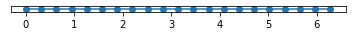

In [4]:
n=20
mesh=IntervalMesh(n, 0, 2*np.pi)
plot(mesh)

## Space Definition

---



In [5]:
k = 1
V = FunctionSpace(mesh, 'CG', k)

Calling FFC just-in-time (JIT) compiler, this may take some time.


In [0]:
u = TrialFunction(V)
v = TestFunction(V)

# the bilinear form in the left-hand side of the formulation is given by
a = dot(grad(u), grad(v)) * dx

# the linear functional in the right-hand side is given by
f = Expression('sin(x[0])', degree=k+1)
L = f * v * dx

## Boundary Condition
---

Dirichlet BC are defined:
  \begin{equation*}
    u(0)= 0, u(2\pi)=0 
  \end{equation*}

In [0]:
uD=Constant(0)
def boundary(x, on_boundary):
  return on_boundary

bc = DirichletBC(V, uD, boundary)

## Resolution

---



In [8]:
u = TrialFunction(V)
v = TestFunction(V)

f = Expression('sin(x[0])', degree=k+1)

RHS = f * v * dx
a = dot(grad(u), grad(v))*dx

u = Function(V)
solve(a==RHS, u, bc)

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


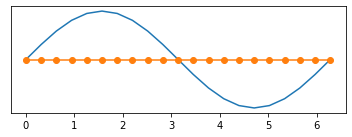

In [9]:
plot(u)
plot(mesh)
plt.show()

# **Method Proprierties**

## Solver Function

In [0]:
def laplacian(n, f, deg, inter0, intern):
  """
  Solve Laplace Problem 1D
  Input: number of elements, function, degree of precision, extremes of the interval
  """
  mesh = IntervalMesh(n, inter0, intern)
  V=FunctionSpace(mesh, 'CG', deg)
  def boundary(x, on_boundary):
    return on_boundary
  uD=Constant(0.0)
  bc = DirichletBC(V, uD, boundary)
  u = TrialFunction(V)
  v= TestFunction(V)
  A= dot(grad(u), grad(v))*dx
  RHS = f*v*dx

  u=Function(V)
  solve(A==RHS, u, bc)
  return u, mesh

## Test

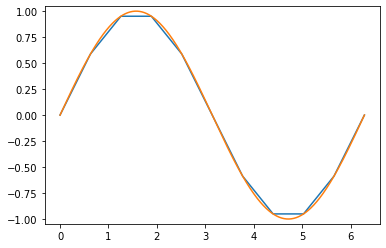

In [11]:
f1=Expression('sin(x[0])', degree=2)
f2=Constant(1)
inter0 = 0
intern = 2*np.pi

u1, mesh=laplacian(10, f1, 1, inter0, intern)
u2, mesh=laplacian(500, f1, 1, inter0, intern)
plot(u1)
plot(u2)
plt.show()

## Convergence

### *Polynomial Approximation Convergence*

In [12]:
f1=Expression('sin(x[0])', degree=2)
f2=Constant(1)

ue1 = Expression('sin(x[0])', degree=2)
ue2 = Expression('pi*x[0]-pow(x[0],2)/2', degree=2)

n=10
errabs_0=[]
errabs_1=[]
errL2_1=[]
errL2_0=[]
for deg in [1, 2]:
  u0, mesh0=laplacian(n, f1, deg, 0, 2*np.pi)
  u1, mesh1=laplacian(n, f2, deg, 0, 2*np.pi)

  u0vect=u0.compute_vertex_values()
  u1vect=u1.compute_vertex_values()
  errvect_0=[]
  errvect_1=[]
  ue1vect=ue1.compute_vertex_values(mesh0)
  ue2vect=ue2.compute_vertex_values(mesh1)
  for i in range(len(u0vect)):
    
    err_0=np.abs(ue1vect[i]-u0vect[i])
    errvect_0.append(err_0)

    err_1=np.abs(ue2vect[i]-u1vect[i])
    errvect_1.append(err_1)

  errL2_1.append(errornorm(ue2, u1, 'L2'))
  errL2_0.append(errornorm(ue1, u0, 'L2'))
  errabs_0.append(max(errvect_0))
  errabs_1.append(max(errvect_1))

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


In [13]:
print('f=sin(x)')
print('L2 Error \n', errL2_0)
print('N2 Error \n', errabs_0)
print()
print('f=1')
print('L2 Error \n', errL2_1)
print('N2 Error \n', errabs_1)

f=sin(x)
L2 Error 
 [0.06358479985687261, 0.002572114688338895]
N2 Error 
 [0.00015747062403104195, 0.00015747062402848844]

f=1
L2 Error 
 [0.09033562380150885, 1.21677260224292e-13]
N2 Error 
 [1.7763568394002505e-15, 6.750155989720952e-14]


### *Mesh Convergence*

In [0]:
def laplacian1(n, f, deg):
  """
  Solve Laplace Problem 1D
  Input: number of elements, function, degree of precision
  """
  mesh = UnitIntervalMesh(n)
  V=FunctionSpace(mesh, 'CG', deg)
  def boundary(x, on_boundary):
    return on_boundary
  uD=Constant(0.0)
  bc = DirichletBC(V, uD, boundary)
  u = TrialFunction(V)
  v= TestFunction(V)
  A= dot(grad(u), grad(v))*dx
  RHS = f*v*dx

  u=Function(V)
  solve(A==RHS, u, bc)
  return u, mesh, V

  Firstly, let's test the problem:
  \begin{cases}
  -u''(x)= 1 & \mbox{in } \Omega(0, 1) \\ u(0)=0 \\  u(1)=0
  \end{cases}
  
  That has the following exact solution:
    \begin{equation*}
    u (x) = x\frac{(1-x)}{2} 
  \end{equation*}

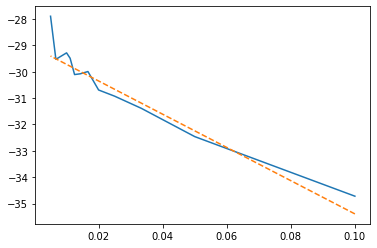

In [20]:
f1 = Constant(1)
u1 = Expression('x[0] * (1 - x[0]) / 2', degree=2+2)
error_max_vect=[]
h=[]
for n in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]:
  uh, mesh, V = laplacian1(n, f1, 2)

  vertex_values_u1 = u1.compute_vertex_values(mesh)
  vertex_values_uh = uh.compute_vertex_values(mesh)

  error_max = np.max(np.abs(vertex_values_uh - vertex_values_u1))
  error_max_vect.append(error_max)
  h.append(1/n)

plt.plot(h, np.log(error_max_vect))
plt.plot([h[0], h[-1]], [-2*np.log(h[0])-40, -2*np.log(h[-1])-40], '--')
plt.savefig('Convergenza1.png', format='png', dpi=600)

  Firstly, let's test the problem:
  \begin{cases}
  -u''(x)= \mbox{sin}(x) & \mbox{in } \Omega(0, 1) \\ u(0)=0 \\  u(1)=0
  \end{cases}
  
  That has the following exact solution:
    \begin{equation*}
    u (x)= \mbox{sin}(x)
  \end{equation*}

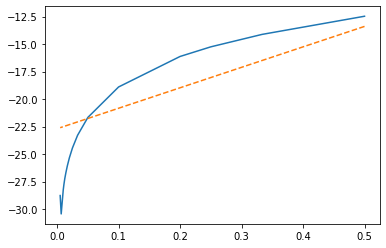

In [37]:
f1 = Expression('sin(x[0])', degree=2)
u1 = Expression('sin(x[0]) -x[0]*sin(1)', degree=2)
error_max_vect=[]
h=[]
for n in [2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]:
  uh, mesh, V = laplacian1(n, f1, 2)

  ui = interpolate(u1,V)

  vertex_values_u1 = u1.compute_vertex_values(mesh)
  vertex_values_uh = uh.compute_vertex_values(mesh)

  error_max = np.max(np.abs(vertex_values_uh - vertex_values_u1))
  error_max_vect.append(error_max)
  h.append(1/n)

plt.plot(h, np.log(error_max_vect))
plt.plot([h[0], h[-1]], [2*np.log(h[0])-12, 2*np.log(h[-1])-12], '--')
plt.savefig('Convergenza2.png', format='png', dpi=600)